In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [3]:
df = pd.read_csv("wine.csv")

df.head()
df.info()
df.describe()
df.replace('?', np.nan, inplace=True)
df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [4]:
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

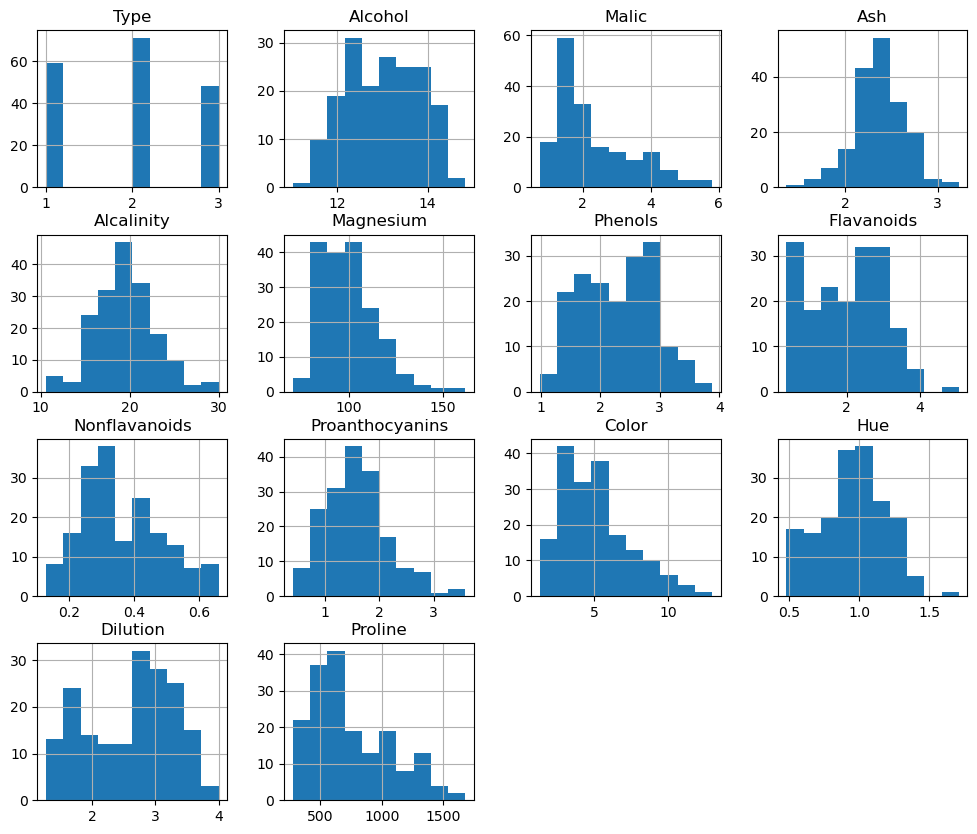

In [5]:
#histogram
df.hist(figsize=(12,10))
plt.show()

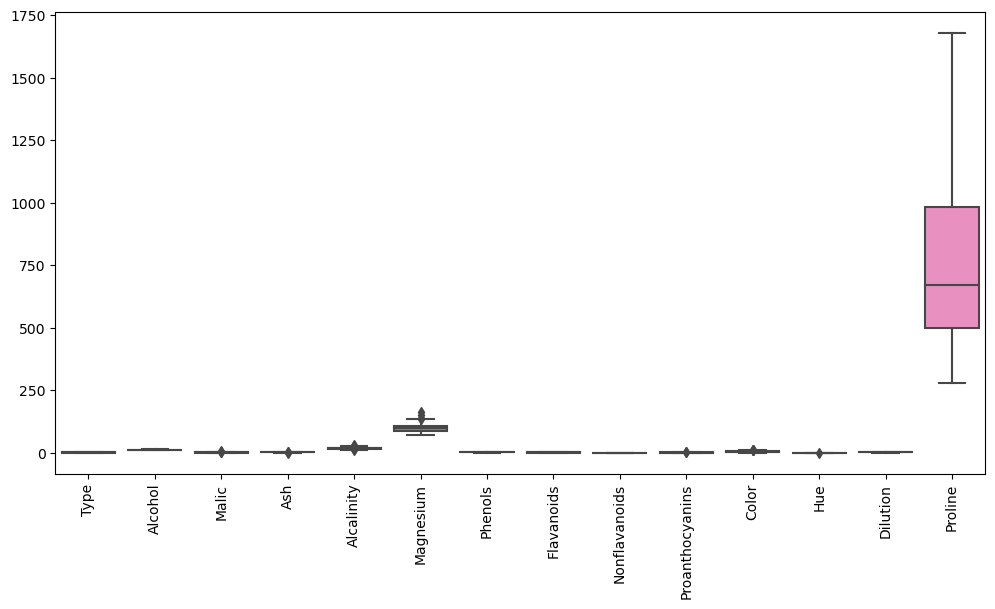

In [6]:
#boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

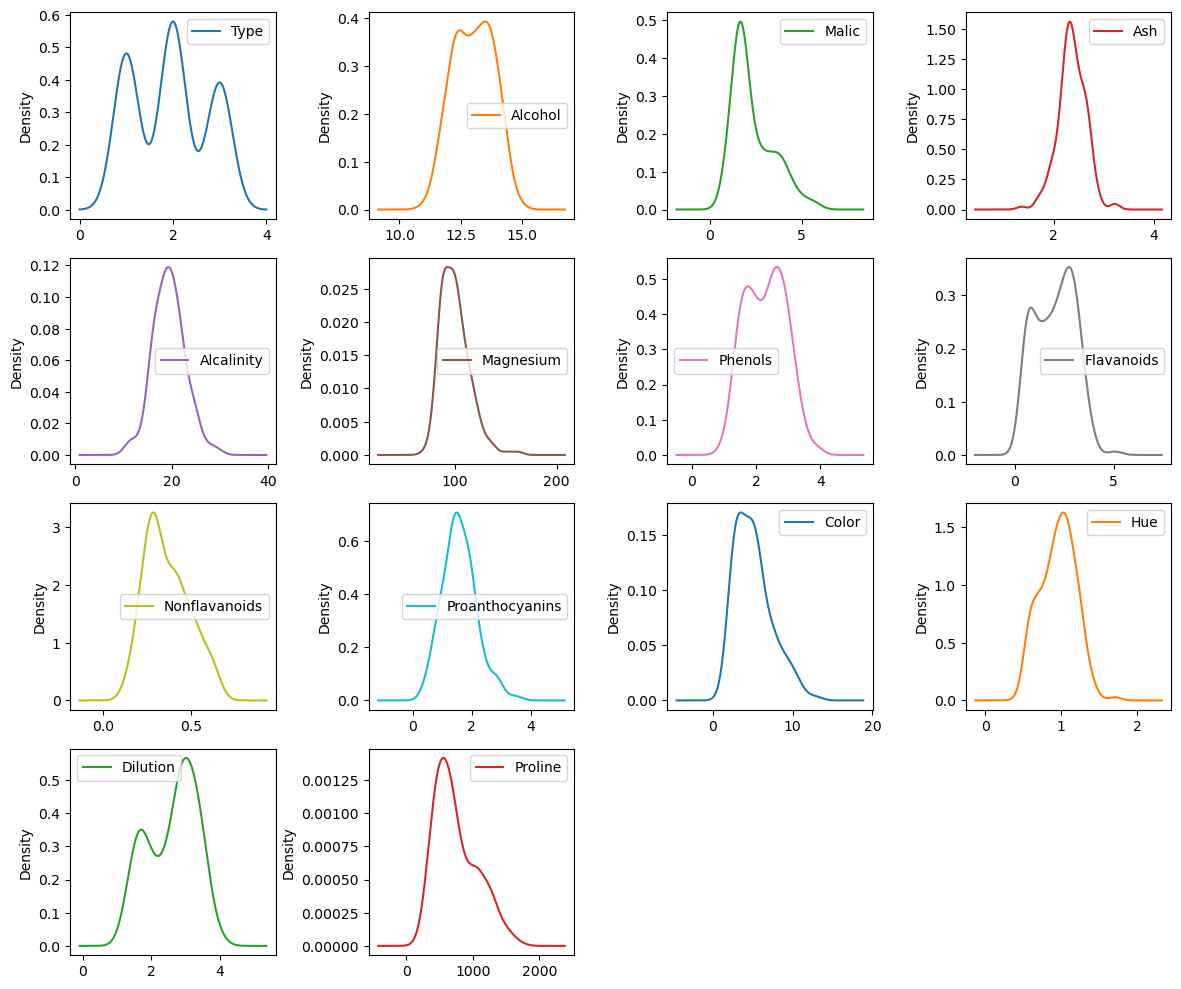

In [7]:
# Density Plot
df.plot(kind='density', subplots=True, layout=(4,4), figsize=(12,10), sharex=False)
plt.tight_layout()
plt.show()

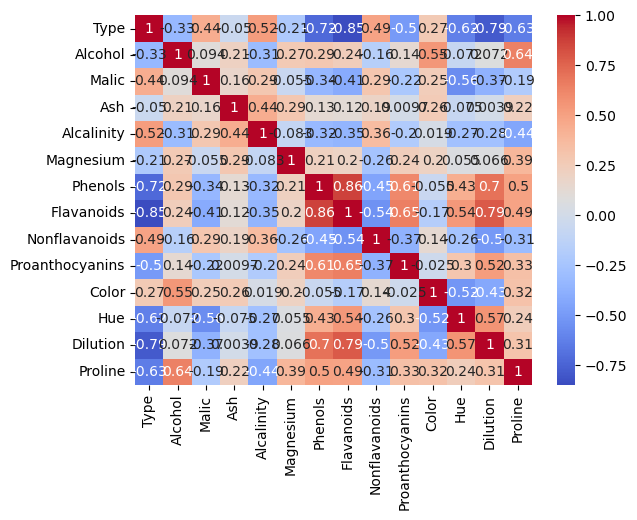

In [8]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [9]:
target_col = "Type"

X = df.drop(target_col, axis=1)
y = df[target_col]

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

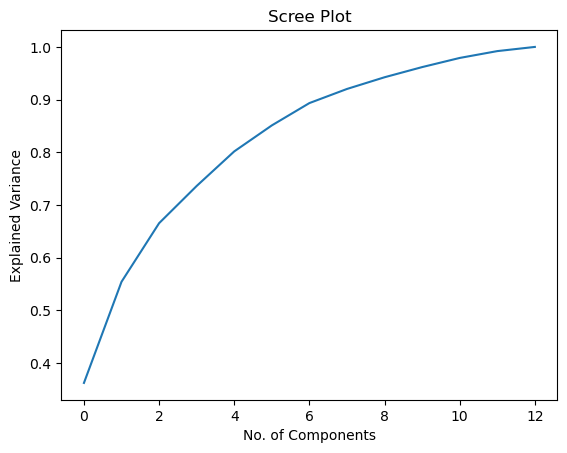

In [12]:
#scree plot
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("No. of Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.show()

C:\Users\SUGANYA P\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\SUGANYA P\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


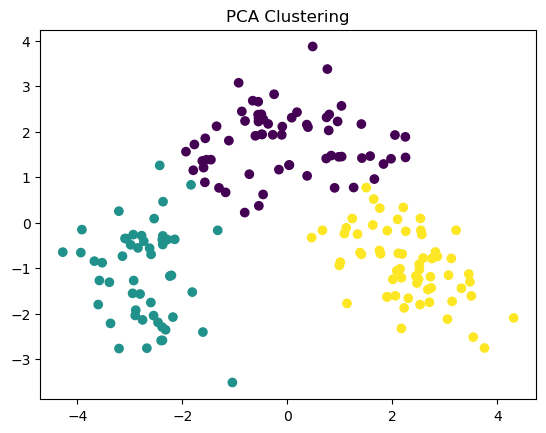

In [13]:
# PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# KMeans on original
kmeans_original = KMeans(n_clusters=3, random_state=42)
clusters_original = kmeans_original.fit_predict(X_scaled)

# KMeans on PCA
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# Plot PCA clustering
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_pca, cmap="viridis")
plt.title("PCA Clustering")
plt.show()

In [14]:
# KMeans on PCA data
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

C:\Users\SUGANYA P\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


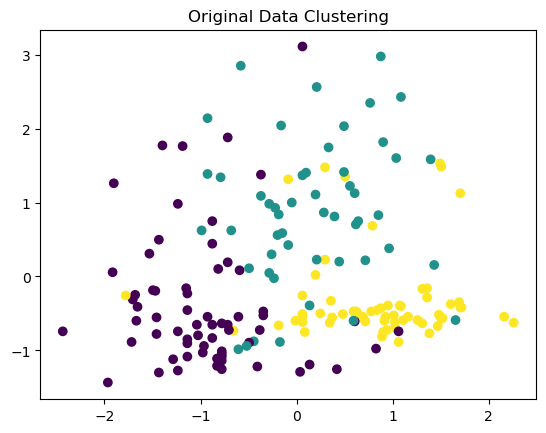

In [15]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_pca, cmap="viridis")
plt.title("Original Data Clustering")
plt.show()

In [16]:
sil_original = silhouette_score(X_scaled, clusters_pca)
db_original = davies_bouldin_score(X_scaled, clusters_pca)

print("Silhouette:", sil_original)
print("DB Index:", db_original)

Silhouette: 0.2848589191898987
DB Index: 1.3891879777181648


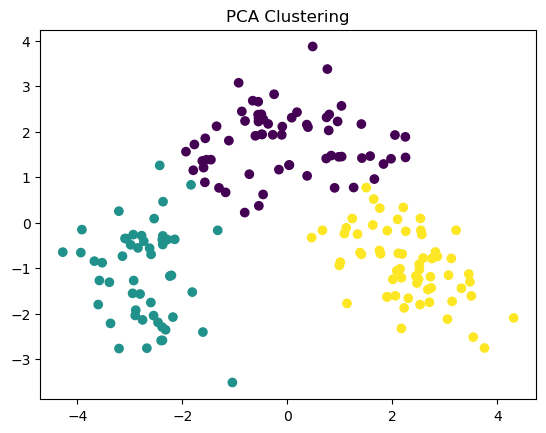

In [17]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_pca, cmap="viridis")
plt.title("PCA Clustering")
plt.show()

In [18]:
sil_pca = silhouette_score(X_pca, clusters_pca)
db_pca = davies_bouldin_score(X_pca, clusters_pca)

print("Silhouette PCA:", sil_pca)
print("DB Index PCA:", db_pca)

Silhouette PCA: 0.2986748294369291
DB Index PCA: 1.3363263335155757


In [19]:
print("Original -> Silhouette:", sil_original, " DB:", db_original)
prin

t("PCA      -> Silhouette:", sil_pca, " DB:", db_pca)

Original -> Silhouette: 0.2848589191898987  DB: 1.3891879777181648
PCA      -> Silhouette: 0.2986748294369291  DB: 1.3363263335155757


C:\Users\SUGANYA P\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\SUGANYA P\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\SUGANYA P\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\SUGANYA P\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureW

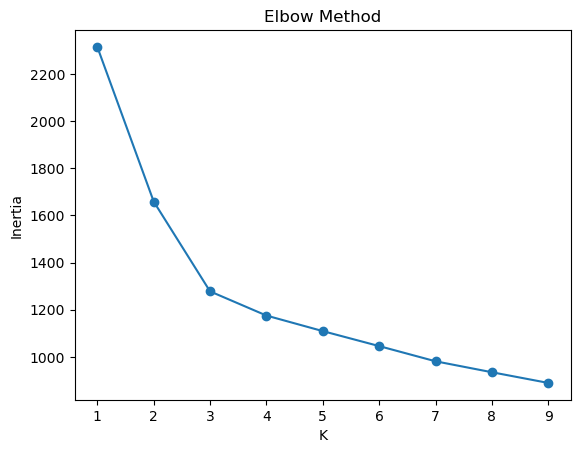

In [20]:
inertia = []

for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()